In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import iplotx as ipx
import random
from matplotlib import animation
import torch
from torch_geometric.nn import Node2Vec

c:\Users\ashto\anaconda3\envs\ddi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Documentation
# Networkx:
#https://networkx.org/documentation/stable/reference/generators.html
# iplotx
# https://iplotx.readthedocs.io/en/latest/
# Maybe..
# from collections import defacultdict
# --> Building edge lists dyanmically, constructing edge list incrementally as we process data
# rater than creating it all at once upfront, can process it chunck by chunck rather than loading everything at once

In [ ]:
# Extract the similarity scores and place the scores in a list of tuples
    # (drug_1,drug_2, 0.700), ....
# Ensure that we are only extracting upper triangle only (extracting both wastes memor and redudant edges)
# Filter by threshold (Skip creating edges for similarities below a certain threshold)

In [ ]:
# Create an extaction method here based on the type of data structure 
# we save the drug_1, drug_2, final sim(P,Q) score in
# Most liekely convert to a list of tuples

In [4]:
# Example Small Dataframe after computing the final Sim(P,Q) score


df_similarities = pd.DataFrame({
    'drug_1': [
        'metformin_glibenc',
        'enalapril_hctz',
        'aspirin_caffeine',
        'ibuprofen_codeine',
        'metformin_glibenc',
        'paracetamol_codeine'
    ],
    'drug_2': [
        'nateglinide',
        'hydrochlorothiazide',
        'acetaminophen',
        'morphine',
        'gliclazide',
        'tramadol'
    ],
    'similarity_score': [
        0.7143,
        0.5000,
        0.8571,
        0.0000,
        0.6667,
        0.5714
    ]
})

In [ ]:

# Create a larger, more complex test dataset
import random

# Drug names for testing
drugs = [
    'metformin', 'glibenclamide', 'nateglinide', 'repaglinide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'voglibose', 'sitagliptin',
    'saxagliptin', 'linagliptin', 'alogliptin', 'vildagliptin', 'exenatide',
    'liraglutide', 'dulaglutide', 'semaglutide', 'insulin_glargine', 'insulin_aspart',
    'insulin_lispro', 'insulin_detemir', 'insulin_degludec', 'enalapril', 'lisinopril',
    'ramipril', 'perindopril', 'trandolapril', 'losartan', 'valsartan',
    'irbesartan', 'candesartan', 'olmesartan', 'telmisartan', 'eprosartan',
    'amlodipine', 'felodipine', 'nifedipine', 'diltiazem', 'verapamil',
    'metoprolol', 'atenolol', 'bisoprolol', 'carvedilol', 'nebivolol',
    'enalapril', 'aspirin', 'clopidogrel', 'ticlopidine', 'warfarin',
    'rivaroxaban', 'apixaban', 'dabigatran', 'edoxaban', 'heparin',
    'ibuprofen', 'naproxen', 'indomethacin', 'ketorolac', 'meloxicam',
    'celecoxib', 'rofecoxib', 'paracetamol', 'acetaminophen', 'codeine',
    'morphine', 'tramadol', 'fentanyl', 'buprenorphine', 'oxycodone',
    'hydrocodone', 'methadone', 'naloxone', 'naltrexone'
]

# Generate a large dataset (500+ pairs with varied similarity scores)
np.random.seed(42)
drug_pairs = []
similarity_scores = []

# Generate combinations with various similarity patterns
for i in range(len(drugs)):
    # Each drug gets paired with 8-12 other drugs
    num_pairs = np.random.randint(8, 13)
    partner_indices = np.random.choice([j for j in range(len(drugs)) if j != i], size=num_pairs, replace=False)
    
    for j in partner_indices:
        if i < j:  # Avoid duplicates (upper triangle only)
            drug_pairs.append((drugs[i], drugs[j]))
            
            # Create realistic similarity scores with different patterns
            # Some pairs very similar, some moderate, some low
            score_type = np.random.choice(['high', 'medium', 'low', 'very_low'], p=[0.2, 0.35, 0.30, 0.15])
            
            if score_type == 'high':
                score = np.random.uniform(0.75, 1.0)
            elif score_type == 'medium':
                score = np.random.uniform(0.45, 0.75)
            elif score_type == 'low':
                score = np.random.uniform(0.15, 0.45)
            else:  # very_low
                score = np.random.uniform(0.0, 0.15)
            
            similarity_scores.append(round(score, 4))

# Create the large dataframe
df_similarities_large = pd.DataFrame({
    'drug_1': [pair[0] for pair in drug_pairs],
    'drug_2': [pair[1] for pair in drug_pairs],
    'similarity_score': similarity_scores
})

print(f"✓ Created test dataset: {len(df_similarities_large)} drug pairs")
print(f"✓ Unique drugs: {len(set(df_similarities_large['drug_1'].tolist() + df_similarities_large['drug_2'].tolist()))}")
print(f"✓ Similarity score range: {df_similarities_large['similarity_score'].min():.4f} - {df_similarities_large['similarity_score'].max():.4f}")
print(f"✓ Mean similarity: {df_similarities_large['similarity_score'].mean():.4f}")
print(f"\nDataset preview:")
print(df_similarities_large.head(10))
print(f"\nDataset statistics:")
print(df_similarities_large['similarity_score'].describe())


In [5]:
df_similarities

,drug_1,drug_2,similarity_score
0,metformin_glibenc,nateglinide,0.7143
1,enalapril_hctz,hydrochlorothiazide,0.5000
2,aspirin_caffeine,acetaminophen,0.8571
3,ibuprofen_codeine,morphine,0.0000
4,metformin_glibenc,gliclazide,0.6667
5,paracetamol_codeine,tramadol,0.5714


In [6]:
# Filter out all entries with a similarity score with zero and output the amount
# This should reduce parsing time
df_similarities_slim = df_similarities[df_similarities['similarity_score'] > 0] 

df_size_difference = len(df_similarities) - len(df_similarities_slim)
print(f'{df_size_difference} entries had a similarity score of 0')

1 entries had a similarity score of 0


In [7]:
df_similarities_slim

,drug_1,drug_2,similarity_score
0,metformin_glibenc,nateglinide,0.7143
1,enalapril_hctz,hydrochlorothiazide,0.5000
2,aspirin_caffeine,acetaminophen,0.8571
4,metformin_glibenc,gliclazide,0.6667
5,paracetamol_codeine,tramadol,0.5714


## Networkx Generation of Graph

In [8]:
G = nx.Graph() # Create a graph object

# Parse using itertuples, excluding the row index and returning plain tuples instead of named tuples
# This should be fasteer than iterating with .iterrows() and cleaner than .values
for drug_1, drug_2, sim_score in df_similarities_slim.itertuples(index=False, name=None): 
    G.add_edge(drug_1,drug_2,weight=sim_score)



## iplotx Visualization of Network
#### Works directly with the Networkx G object
#### Interactive visualization
#### Performance: optimized for rendering large networks efficiently
#### Better Styling
#### Can be used to visually evalulate the graphical structure before implementing node2vec

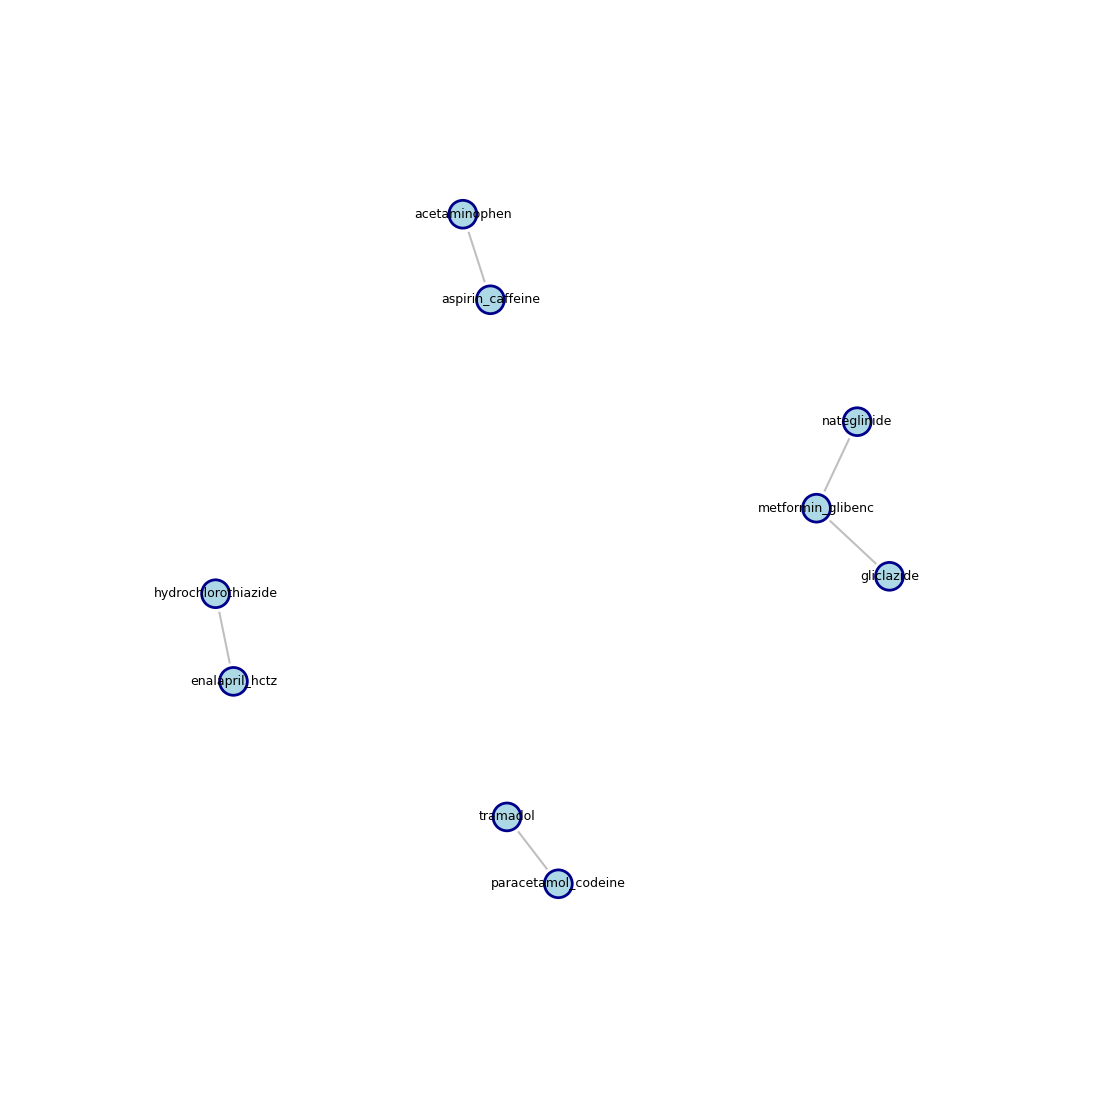

In [9]:
layout = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# Encode edge weights (similarity scores) as visual properties
edge_widths = [G[u][v]['weight'] * 3 for u, v in G.edges()]

ipx.network(
    G, 
    layout,
    # Node styling
    node_marker="o",
    node_size=20,
    node_facecolor="lightblue",
    node_edgecolor="darkblue",
    node_linewidth=2,
    node_labels=True,
    node_label_color="black",
    node_label_fontsize=9,
    # Edge styling - width reflects similarity
    edge_color="gray",  
    edge_alpha=0.5,
    edge_shrink=3,
    # Drawing order
    edge_zorder=2,
    node_zorder=3,
    # Figure options
    margins=0.2,
    figsize=(14, 14)
)

In [ ]:
### Cool random walk animation 

In [26]:
nodes = list(G.nodes())
edges = list(G.edges())

In [30]:
print(nodes,edges)

['metformin_glibenc', 'nateglinide', 'enalapril_hctz', 'hydrochlorothiazide', 'aspirin_caffeine', 'acetaminophen', 'gliclazide', 'paracetamol_codeine', 'tramadol'] [('metformin_glibenc', 'nateglinide'), ('metformin_glibenc', 'gliclazide'), ('enalapril_hctz', 'hydrochlorothiazide'), ('aspirin_caffeine', 'acetaminophen'), ('paracetamol_codeine', 'tramadol')]
